/var/folders/km/pql1mrbj65jbf346hp94yd3h0000gn/T/ipykernel_50412/4132410530.py:15: DeprecationWarning: ast.Num is deprecated and will be removed in Python 3.14; use ast.Constant instead
  if not isinstance(node, allowed_nodes):


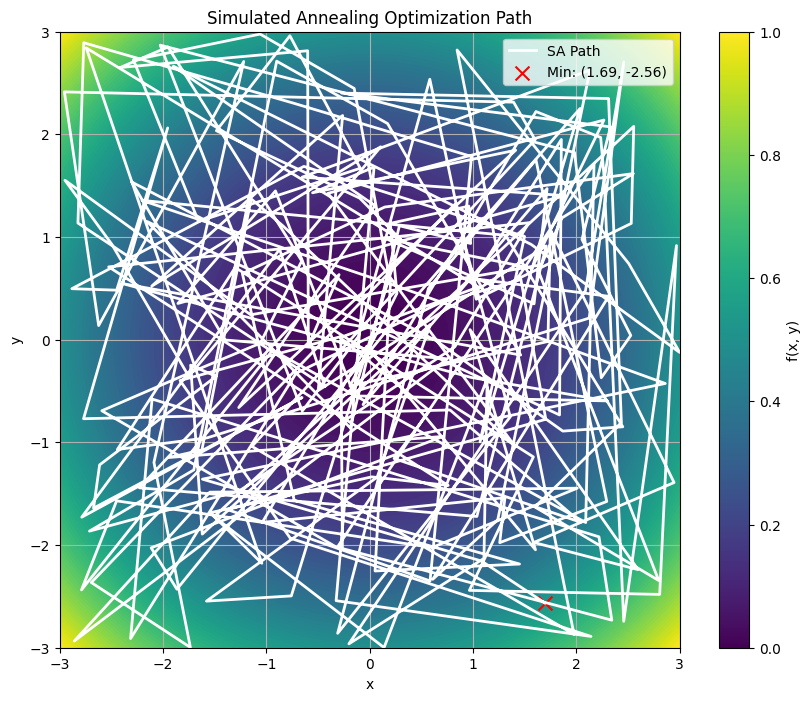

Minimum value found: f(1.6945, -2.5644) = 9.4478


In [32]:
import numpy as np
import matplotlib.pyplot as plt
import ast

def parse_function(expr):
    """
    Safely parse a user-input expression string to a Python lambda function of two variables (x, y)
    """
    expr_ast = ast.parse(expr, mode='eval')
    allowed_nodes = (ast.Expression, ast.BinOp, ast.UnaryOp, ast.Num, ast.Name, ast.Load,
                     ast.Add, ast.Sub, ast.Mult, ast.Div, ast.Pow,
                     ast.Call, ast.Constant)

    for node in ast.walk(expr_ast):
        if not isinstance(node, allowed_nodes):
            raise ValueError("Unsafe expression detected. Only math operations with x and y are allowed.")
    
    return lambda x, y: eval(expr, {"x": x, "y": y, "np": np})

def SA_2D(func, T=5, max_iter=500, bounds=[-3, 3]):
    scale = np.sqrt(T)
    x, y = np.random.uniform(bounds[0], bounds[1]), np.random.uniform(bounds[0], bounds[1])
    cur = func(x, y)
    history = [(x, y)]

    for _ in range(max_iter):
        dx, dy = np.random.normal(scale=scale, size=2)
        x_prop, y_prop = x + dx, y + dy

        if not (bounds[0] <= x_prop <= bounds[1] and bounds[0] <= y_prop <= bounds[1]):
            x_prop, y_prop = x, y

        new_val = func(x_prop, y_prop)

        if new_val < cur or np.log(np.random.rand()) * T > cur - new_val:
            x, y = x_prop, y_prop
            cur = new_val

        T *= 0.9
        history.append((x, y))

    return (x, y), history, cur

def run_calculator(expr):
    func = parse_function(expr)

    (x_min, y_min), path, min_val = SA_2D(func, T=5, max_iter=500, bounds=[-3, 3])

    path = np.array(path)

    X = np.linspace(-3, 3, 300)
    Y = np.linspace(-3, 3, 300)
    XX, YY = np.meshgrid(X, Y)
    ZZ = np.vectorize(func)(XX, YY)

    plt.figure(figsize=(10, 8))
    plt.contourf(XX, YY, ZZ, levels=100, cmap='viridis')
    plt.plot(path[:, 0], path[:, 1], color='white', lw=2, label='SA Path')
    plt.scatter(x_min, y_min, color='red', marker='x', s=100, label=f'Min: ({x_min:.2f}, {y_min:.2f})')
    plt.colorbar(label='f(x, y)')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Simulated Annealing Optimization Path')
    plt.legend()
    plt.grid(True)
    plt.show()

    print(f"Minimum value found: f({x_min:.4f}, {y_min:.4f}) = {min_val:.4f}")

# Example usage:
run_calculator("x**2+y**2")
